# Library

In [1]:
import os
import ssl
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Bypass SSL verification for macOS dataset downloading issues
ssl._create_default_https_context = ssl._create_unverified_context

# Modular project imports
from configs.config import DiffusionConfig
from utils.tools import setup_directories, show_images, plot_losses
from models.unet import UNet
from models.diffusion import Diffusion

In [2]:
def set_seed(seed: int = 42):
    """Enforces random seed setting for reproducibility."""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        
set_seed(42)
setup_directories()

device = torch.device(DiffusionConfig.DEVICE)
print(f"Device initialized: {device}")

Device initialized: mps


# Data



In [3]:
# MNIST Processing Pipeline (Resize to 32x32, normalize to [-1, 1])
transform = transforms.Compose([
    transforms.Resize((DiffusionConfig.IMG_SIZE, DiffusionConfig.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(
    train_dataset,
    batch_size=DiffusionConfig.BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Optimized to 0 to bypass multiprocessing lag on macOS
    pin_memory=True
)

print(f"Dataset loaded. Total batches: {len(train_loader)}")

Dataset loaded. Total batches: 469


In [4]:
# Fetch raw MNIST statistics (without normalization or resize transformations)
raw_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
raw_img, raw_label = raw_dataset[0]
print("=== Original MNIST Dataset Statistics ===")
print(f"Image Shape and Number of Channels: {list(raw_img.shape)}")
print(f"Max pixel value: {raw_img.max().item():.1f}, Min pixel value: {raw_img.min().item():.1f}")
print(f"Total number of training samples: {len(raw_dataset)}")
print(f"Class names (Labels): {raw_dataset.classes}")

=== Original MNIST Dataset Statistics ===
Image Shape and Number of Channels: [1, 28, 28]
Max pixel value: 1.0, Min pixel value: 0.0
Total number of training samples: 60000
Class names (Labels): ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


In [5]:
# Fetch processed batch statistics from the train_loader
data_iter = iter(train_loader)
batch_images, batch_labels = next(data_iter)
print("=== Processed Training Batch Statistics ===")
print(f"New batch shape: {list(batch_images.shape)}")
print(f"Normalized Max pixel value: {batch_images.max().item():.1f}, Min pixel value: {batch_images.min().item():.1f}")
print(f"Sample labels in this batch: {batch_labels[:10].tolist()}")

=== Processed Training Batch Statistics ===
New batch shape: [128, 1, 32, 32]
Normalized Max pixel value: 1.0, Min pixel value: -1.0
Sample labels in this batch: [1, 2, 8, 5, 2, 6, 9, 9, 9, 4]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


=== Visualizing Processed Training Batch Samples ===


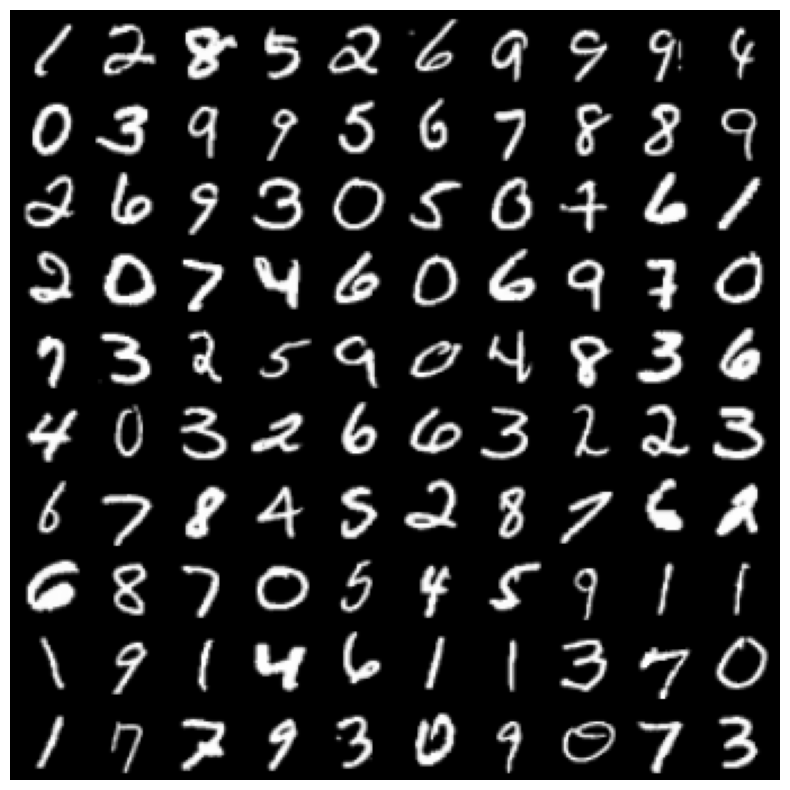

In [6]:
# Visualize a batch of training images (un-normalized and grid-formed automatically)
print("=== Visualizing Processed Training Batch Samples ===")
show_images(batch_images[:100], num_rows=10)

# Model Initialization

Instantiates U-Net and Diffusion modules with high capacity and Cosine scheduler.

In [7]:
# Symmetrical U-Net noise predictor model with optimized capacity (base_channels=64)
model = UNet(
    in_channels=DiffusionConfig.CHANNELS,
    out_channels=DiffusionConfig.CHANNELS,
    base_channels=64,  # Configured to 64 for fast prototyping on MPS
    num_classes=DiffusionConfig.NUM_CLASSES
).to(device)

# Diffusion engine configured with the Cosine schedule
diffusion = Diffusion(
    timesteps=DiffusionConfig.TIMESTEPS,
    beta_start=DiffusionConfig.BETA_START,
    beta_end=DiffusionConfig.BETA_END,
    schedule_type="cosine"
).to(device)

optimizer = optim.Adam(model.parameters(), lr=DiffusionConfig.LR)

print(f"Model (base_channels=64), Cosine Diffusion engine, and Adam optimizer initialized.")

Model (base_channels=64), Cosine Diffusion engine, and Adam optimizer initialized.


# Training

Executes parameter optimization, stores weights, and plots intermediate samples to monitor generation quality every 5 epochs.

Beginning training process...
Epoch [01/25] | Average MSE Loss: 0.090708
Epoch [02/25] | Average MSE Loss: 0.040542
Epoch [03/25] | Average MSE Loss: 0.035718
Epoch [04/25] | Average MSE Loss: 0.033304
Epoch [05/25] | Average MSE Loss: 0.031988
Checkpoint saved: checkpoints/ddpm_mnist_epoch_5.pth
--- Visual progress grid at Epoch 5 ---


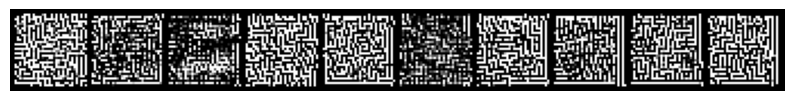

Epoch [06/25] | Average MSE Loss: 0.030527
Epoch [07/25] | Average MSE Loss: 0.029784
Epoch [08/25] | Average MSE Loss: 0.029444
Epoch [09/25] | Average MSE Loss: 0.028977
Epoch [10/25] | Average MSE Loss: 0.028632
Checkpoint saved: checkpoints/ddpm_mnist_epoch_10.pth
--- Visual progress grid at Epoch 10 ---


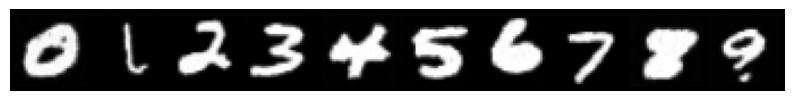

Epoch [11/25] | Average MSE Loss: 0.028405
Epoch [12/25] | Average MSE Loss: 0.028149
Epoch [13/25] | Average MSE Loss: 0.027895
Epoch [14/25] | Average MSE Loss: 0.027840
Epoch [15/25] | Average MSE Loss: 0.027362
Checkpoint saved: checkpoints/ddpm_mnist_epoch_15.pth
--- Visual progress grid at Epoch 15 ---


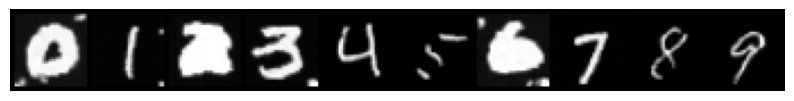

Epoch [16/25] | Average MSE Loss: 0.027143
Epoch [17/25] | Average MSE Loss: 0.027144
Epoch [18/25] | Average MSE Loss: 0.027109
Epoch [19/25] | Average MSE Loss: 0.026931
Epoch [20/25] | Average MSE Loss: 0.026719
Checkpoint saved: checkpoints/ddpm_mnist_epoch_20.pth
--- Visual progress grid at Epoch 20 ---


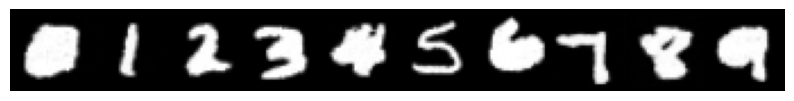

Epoch [21/25] | Average MSE Loss: 0.026828
Epoch [22/25] | Average MSE Loss: 0.026600
Epoch [23/25] | Average MSE Loss: 0.026556
Epoch [24/25] | Average MSE Loss: 0.026357
Epoch [25/25] | Average MSE Loss: 0.026268
Checkpoint saved: checkpoints/ddpm_mnist_epoch_25.pth
--- Visual progress grid at Epoch 25 ---


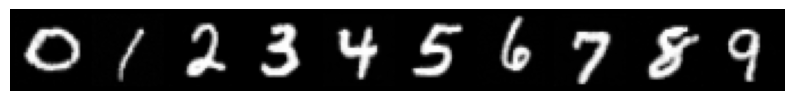

In [8]:
print("Beginning training process...")
loss_history = []

for epoch in range(DiffusionConfig.EPOCHS):
    model.train()
    epoch_losses = []
    
    for batch_idx, (batch_images, batch_labels) in enumerate(train_loader):
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        
        optimizer.zero_grad()
        
        t = torch.randint(0, DiffusionConfig.TIMESTEPS, (batch_images.shape[0],), device=device)
        loss = diffusion.get_loss(model, batch_images, batch_labels, t, p_uncond=0.1)
        
        loss.backward()
        optimizer.step()
        
        epoch_losses.append(loss.item())
        
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1:02d}/{DiffusionConfig.EPOCHS:02d}] | Average MSE Loss: {avg_loss:.6f}")
    
    # Save model weight state checkpoints every 5 epochs
    if (epoch + 1) % 5 == 0 or (epoch + 1) == DiffusionConfig.EPOCHS:
        checkpoint_path = f"checkpoints/ddpm_mnist_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Checkpoint saved: {checkpoint_path}")
        
        # Generate intermediate visual grid to monitor sampling quality progress (1 sample per digit 0-9)
        print(f"--- Visual progress grid at Epoch {epoch+1} ---")
        test_c = torch.arange(10, device=device)
        intermediate_samples = diffusion.sample(
            model=model,
            num_samples=10,
            channels=DiffusionConfig.CHANNELS,
            img_size=DiffusionConfig.IMG_SIZE,
            device=device,
            c=test_c,
            cfg_scale=3.0
        )
        grid_path = f"outputs/grid_epoch_{epoch+1}.png"
        show_images(intermediate_samples, save_path=grid_path, num_rows=1)

# Loss Curve Analysis

Plots training MSE loss to trace score-matching convergence.

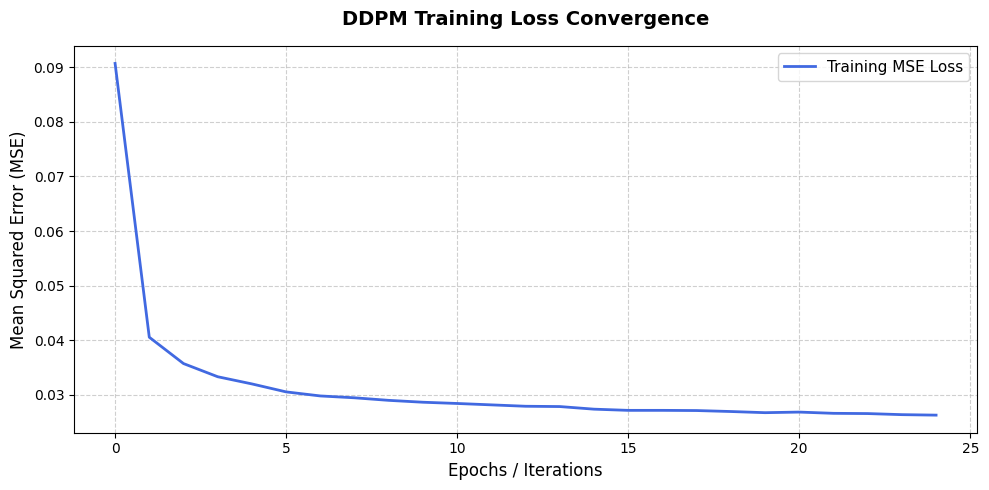

In [9]:
# Plot the loss convergence curve
plot_losses(loss_history, save_path="outputs/loss_curve.png")

# Conditional Sampling

Generates 100 conditional digit images (10 samples per digit 0-9) using CFG with scale w=3.0.

Generating final high-fidelity class-conditional digits...


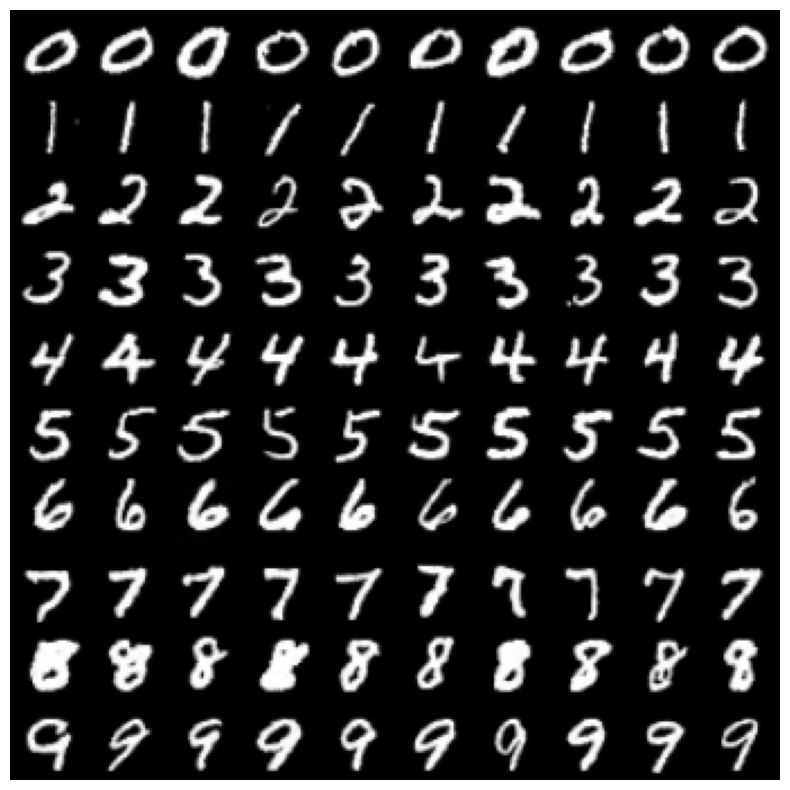

In [10]:
# Define condition class labels representing digits 0 to 9 (10 samples of each digit)
c_samples = torch.tensor([digit for digit in range(10) for _ in range(10)], device=device)

print("Generating final high-fidelity class-conditional digits...")
generated_images = diffusion.sample(
    model=model,
    num_samples=100,
    channels=DiffusionConfig.CHANNELS,
    img_size=DiffusionConfig.IMG_SIZE,
    device=device,
    c=c_samples,
    cfg_scale=3.0
)

# Display grid and save to disk
show_images(generated_images, save_path="outputs/generated_grid.png", num_rows=10)